In [794]:
import numpy as np
import pandas as pd
import re

In [795]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [796]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')

In [797]:
df.duplicated().sum()

121

In [798]:
df.head(1)
# focus is on -> areaWithType, additionalRoom, agePossession, furnishDetails, features 

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features
0,house,bptp astaire gardens,sector 70a,6.5,27871.0,2332.0,Plot area 299(250 sq.m.),4,4,3+,"study room,servant room,pooja room",2.0,North-East,0 to 1 Year Old,"['Sector 54 Chowk Metro Station', 'Airia Mall', 'Southern Peripheral Road', 'Badshahpur Sohna Rd Hwy', 'Kunskapsskolan International School', 'DPG Degree College', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Intellion Edge', 'Hyatt Regency Gurgaon', 'De Adventure Park', 'Tau DeviLal Sports Complex']","['5 Wardrobe', '9 Fan', '5 Geyser', '1 Stove', '18 Light', '8 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']"


## 1. areaWithType

In [800]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
1390,0.48,1099.0,Super Built up area 1099(102.1 sq.m.)
3184,0.27,497.0,Carpet area: 497 (46.17 sq.m.)
2294,1.40,1490.0,Carpet area: 1490 (138.43 sq.m.)
2782,2.20,1966.0,Super Built up area 2100(195.1 sq.m.)
685,4.30,1467.0,Plot area 163(136.29 sq.m.)


In [801]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [802]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [803]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [804]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [805]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
788,0.90,flat,1825.0,Super Built up area 1825(169.55 sq.m.),1825.0,NaN,NaN
473,2.40,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
534,1.34,flat,1304.0,Super Built up area 1304(121.15 sq.m.),1304.0,NaN,NaN
153,1.40,flat,1538.0,Super Built up area 1538(142.88 sq.m.),1538.0,NaN,NaN
783,1.40,flat,1400.0,Carpet area: 1400 (130.06 sq.m.),NaN,NaN,1400.0


In [806]:
df.duplicated().sum()

121

In [807]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [808]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,6.50,house,2332.0,Plot area 299(250 sq.m.),NaN,NaN,NaN
11,12.25,house,5850.0,Plot area 5850(543.48 sq.m.),NaN,NaN,NaN
16,0.40,house,450.0,Plot area 50(41.81 sq.m.),NaN,NaN,NaN
20,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
21,3.71,house,1872.0,Plot area 208(173.91 sq.m.),NaN,NaN,NaN


In [809]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [810]:
# adding the the rows whose all 3 column values missing
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [811]:
all_nan_df.shape

(546, 7)

In [812]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,6.50,house,2332.0,Plot area 299(250 sq.m.),NaN,NaN,NaN
11,12.25,house,5850.0,Plot area 5850(543.48 sq.m.),NaN,NaN,NaN
16,0.40,house,450.0,Plot area 50(41.81 sq.m.),NaN,NaN,NaN
20,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,NaN,NaN
21,3.71,house,1872.0,Plot area 208(173.91 sq.m.),NaN,NaN,NaN


In [813]:
# Storing all the index of these column
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [814]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [815]:
# Plot area = built_up_area

all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

# Update the original dataframe
#gurgaon_properties.update(filtered_rows)

In [816]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,6.50,house,2332.0,Plot area 299(250 sq.m.),NaN,299.00,NaN
11,12.25,house,5850.0,Plot area 5850(543.48 sq.m.),NaN,5850.00,NaN
16,0.40,house,450.0,Plot area 50(41.81 sq.m.),NaN,50.00,NaN
20,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.00,NaN
21,3.71,house,1872.0,Plot area 208(173.91 sq.m.),NaN,208.00,NaN
23,3.25,house,981.0,Plot area 109(91.14 sq.m.),NaN,109.00,NaN
42,5.80,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.00,NaN
43,3.50,house,1449.0,Plot area 161(134.62 sq.m.),NaN,161.00,NaN
65,2.00,house,1800.0,Plot area 200(167.23 sq.m.),NaN,200.00,NaN
76,19.50,house,8775.0,Plot area 975(815.22 sq.m.),NaN,975.00,NaN


In [817]:
# To Bring  all into sq_ft

def convert_scale(row):
    # If either 'area' or 'built_up_area' is missing (NaN),
    # return the built_up_area as it is
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    
    else:
        # Calculate the ratio between area and built_up_area
        # and round it to identify scaling pattern
        ratio = round(row['area'] / row['built_up_area'])
        
        # If area ≈ 9 × built_up_area, scale built_up_area by 9
        if ratio == 9.0:
            return row['built_up_area'] * 9
        
        # If area ≈ 11 × built_up_area, scale built_up_area by 10.7
        elif ratio == 11.0:
            return row['built_up_area'] * 10.7
        
        # Otherwise, return built_up_area without scaling
        else:
            return row['built_up_area']

In [818]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [819]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,6.50,house,2332.0,Plot area 299(250 sq.m.),NaN,299.00,NaN
11,12.25,house,5850.0,Plot area 5850(543.48 sq.m.),NaN,5850.00,NaN
16,0.40,house,450.0,Plot area 50(41.81 sq.m.),NaN,450.00,NaN
20,6.50,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.00,NaN
21,3.71,house,1872.0,Plot area 208(173.91 sq.m.),NaN,1872.00,NaN
23,3.25,house,981.0,Plot area 109(91.14 sq.m.),NaN,981.00,NaN
42,5.80,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.00,NaN
43,3.50,house,1449.0,Plot area 161(134.62 sq.m.),NaN,1449.00,NaN
65,2.00,house,1800.0,Plot area 200(167.23 sq.m.),NaN,1800.00,NaN
76,19.50,house,8775.0,Plot area 975(815.22 sq.m.),NaN,8775.00,NaN


In [820]:
# update the original dataframe
df.update(all_nan_df)

In [821]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                    18
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [822]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area
0,house,bptp astaire gardens,sector 70a,6.50,27871.0,2332.0,Plot area 299(250 sq.m.),4,4,3+,"study room,servant room,pooja room",2.0,North-East,0 to 1 Year Old,"['Sector 54 Chowk Metro Station', 'Airia Mall', 'Southern Peripheral Road', 'Badshahpur Sohna Rd Hwy', 'Kunskapsskolan International School', 'DPG Degree College', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Intellion Edge', 'Hyatt Regency Gurgaon', 'De Adventure Park', 'Tau DeviLal Sports Complex']","['5 Wardrobe', '9 Fan', '5 Geyser', '1 Stove', '18 Light', '8 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,299.0,NaN
1,house,central park flower valley cerise floors,sector 33,1.35,11157.0,1210.0,Built Up area: 1210 (112.41 sq.m.),2,2,2,study room,4.0,East,0 to 1 Year Old,"['Sector 55-56, Sector 56', 'M3m 65th Avenue Mall', 'Emerald Plaza Mall', 'Omaxe City Centre', 'Airia Mall', 'Basant Valley Global School', 'CK Birla Hospital, Gurgaon', 'Park Hospital (Gurugram, Haryana)', 'W Pratiksha Hospital', 'Artemis Hospital Gurgaon', 'Suncity Success Tower', 'Splendor Trade Tower', 'Emaar Digital Greens Tower A', '24 Seven Filling Station', 'HP PETROL PUMP, Golf Course Ext Rd']","['3 Fan', '1 Fridge', '1 Washing Machine', '1 Microwave', '3 Light', '1 Chimney', '3 AC', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",NaN,1210.0,NaN
2,flat,conscient heritage max,sector 102,1.82,9371.0,1942.0,Super Built up area 1942(180.42 sq.m.),3,4,3+,servant room,15.0,East,5 to 10 Year Old,"['Huda Metro Station', 'Ocus Medley Mall', 'The Esplanade Mall', 'Gurugram Road', 'Dwarka Expy', 'Prime Scholars International School', 'DPG Degree College', 'The Signature Advanced Super Speciality', 'Indira Gandhi Intl Airport', 'Basai Dhankot Railway Station', 'Altrade Business Centre', 'Holiday Inn Gurugram Sector 90', 'SkyJumper Trampoline Park Gurgaon', 'Hamoni Golf Camp', 'Nehru Stadium']","['5 AC', '1 Modular Kitchen', '1 Chimney', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Geyser', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Water purifier', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Natural Light', 'Internet/wi-fi connectivity', 'Airy Rooms', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Dispos

## 2.additionalRoom

In [824]:
df['additionalRoom'].value_counts()

additionalRoom
not available                                    1587
servant room                                      705
study room                                        250
others                                            225
pooja room                                        165
store room                                         99
study room,servant room                            99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,store room                              15
pooja room,st

In [825]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [826]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
1054,store room,0,0,1,0,0
614,not available,0,0,0,0,0
2784,"pooja room,study room,servant room,others",1,1,0,1,1
2434,not available,0,0,0,0,0
2825,store room,0,0,1,0,0


In [827]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others
2067,flat,central park resorts,sector 48,5.15,20900.0,2464.0,Super Built up area 2464(228.91 sq.m.)Built Up area: 2364 sq.ft. (219.62 sq.m.)Carpet area: 2264 sq.ft. (210.33 sq.m.),3,3,3+,servant room,8.0,North-West,5 to 10 Year Old,"['Huda Metro Station', 'Omaxe Celebration Mall', 'Iffco Chowk', 'GD Goenka Public School', 'Cambridge College Of Education', 'Gurugram University', 'Park Hospital', 'Indira Gandhi Int. Airport', 'Basai Dhankot']","['1 Water Purifier', '6 Fan', '1 Fridge', '1 Exhaust Fan', '4 Geyser', '1 Stove', '11 Light', '7 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', '3 Wardrobe', '1 Washing Machine', '1 Microwave', 'No Bed', 'No Dining Table', 'No Sofa', 'No TV']","['Power Back-up', 'Intercom Facility', 'Lift(s)', 'Swimming Pool', 'Separate entry for servant room', 'Park', 'Piped-gas', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']",2464.0,2364.0,2264.0,0,1,0,0,0
278,flat,sare green parc phase 3,sector 92,0.95,4856.0,1956.0,Super Built up area 1956(181.72 sq.m.),4,3,3,not available,4.0,North,5 to 10 Year Old,"['Huda Metro Station', 'Sector Road', 'Delhi-Jaipur Expressway', 'Management Development Institute', 'Ajanta Public School', 'The NorthCap University', 'Fortis Memorial Research Institute', 'Indira Gandhi Intl Airport', 'Signature Towers', 'Crowne Plaza Gurgaon', 'Kingdom of Dreams']",NaN,"['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Park', 'Visitor Parking', 'Airy Rooms', 'Spacious Interiors']",1956.0,NaN,NaN,0,0,0,0,0
1521,flat,emaar mgf emerald floors premier,sector 65,2.50,15151.0,1650.0,Super Built up area 1650(153.29 sq.m.),3,3,3,"study room,servant room",3.0,South-West,1 to 5 Year Old,"['WorldMark Gurgaon', 'Sohna Road', 'Golf Course Road', 'CK Birla Hospital', 'Delhi International Airport', 'Lemon Tree Hotel']",[],"['Intercom Facility', 'Lift(s)', 'Park']",1650.0,NaN,NaN,1,1,0,0,0
949,flat,experion the heartsong,sector 108,1.20,6825.0,1758.0,Super Built up area 1758(163.32 sq.m.)Built Up area: 1550 sq.ft. (144 sq.m.)Carpet area: 1400 sq.ft. (130.06 sq.m.),3,2,3+,"servant room,pooja room",11.0,North-East,1 to 5 Year Old,"['Galleria 108 Mall', 'Dwarka Expressway', 'Central Peripheral Road', 'The Shikshiyan School', 'Manipal Hospital', 'Indira Gandhi International Airport', 'Vivanta New Delhi, Dwarka', 'SkyJumper Trampoline Park', 'Fun N Food Village']","['5 Fan', '1 Exhaust Fan', '2 Geyser', '5 Light', '1 Modular Kitchen', '5 AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Power Back-up', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Water softening plant', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']",1758.0,1550.0,1400.0,0,1,0,1,0
1288,flat,emaar mgf the palm drive,sector 66,3.40,15454.0,2200.0,Super Built up area 2200(204.39 sq.m.),3,4,3,"servant room,store room",9.0,East,1 to 5 Year Old,"['Sector 55-56 Rapid Metro Station', 'HUB 66', 'NH 248A', 'Hasanpur', 'Ashoka International School',

## 3.agePossession

In [829]:
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Jan 2024                 8
Oct 2024                 8
Aug 2023                 7
Dec 2025                 7
Jun 2024                 7
Nov 2023                 5
Oct 2023                 4
Aug 2024                 4
Jul 2024                 4
By 2025                  4
Sep 2023                 4
Nov 2024                 3
Jan 2025                 3
May 2024                 3
Feb 2024                 3
Aug 2025                 2
Jun 2027                 2
Jul 2027                 2
Apr 2026                 2
Jan 2026                 2
Mar 2025                 2
Oct 2025                 2
By 2027                  2
Sep 2025      

In [830]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"  

In [831]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [832]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: count, dtype: int64

In [833]:
df.head(0)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others


## 4.furnishDetails

In [835]:
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
3049,[],"['Feng Shui / Vaastu Compliant', 'False Ceiling Lighting', 'Separate entry for servant room', 'Park', 'Internet/wi-fi connectivity', 'Club house / Community Center']"
3155,NaN,['Visitor Parking']
2710,"['2 Fan', '3 Light', 'No AC', 'No Bed', 'No Chimney', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Modular Kitchen', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Piped-gas', 'Visitor Parking', 'Swimming Pool', 'Park', 'Internet/wi-fi connectivity', 'Shopping Centre', 'Fitness Centre / GYM', 'Rain Water Harvesting', 'Club house / Community Center']"
1826,"['2 Wardrobe', '3 Fan', '1 Exhaust Fan', '1 Geyser', '10 Light', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No AC', 'No Bed', 'No Dining Table', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Security / Fire Alarm', 'Power Back-up', 'Intercom Facility', 'Lift(s)', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'Visitor Parking', 'Swimming Pool', 'Park', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center']"
1176,[],"['Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Low Density Society', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']"


In [836]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
/var/folders/_c/bfrh3pms4m58z8m7cf3g56jh0000gn/T/ipykernel_12550/2118040236.py:13: SyntaxWarning: invalid escape sequence '\d'
  pattern = re.compile(f"(\d+) {furnishing}")


In [837]:
furnishings_df.shape

(3803, 19)

In [838]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

/var/folders/_c/bfrh3pms4m58z8m7cf3g56jh0000gn/T/ipykernel_12550/114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [839]:
furnishings_df.sample(5)

,Bed,Washing Machine,Wardrobe,Curtains,AC,Light,TV,Fan,Modular Kitchen,Exhaust Fan,Dining Table,Chimney,Microwave,Sofa,Fridge,Geyser,Water Purifier,Stove
2223,12,0,12,1,12,12,12,12,1,1,0,0,0,0,1,12,0,0
981,1,0,0,1,1,1,0,1,0,1,0,1,0,1,1,0,1,0
2685,0,0,0,0,5,5,0,5,1,1,0,1,0,0,0,0,0,0
2729,0,0,2,0,0,10,0,5,1,0,0,0,0,0,0,0,0,0
2997,0,0,0,0,5,0,0,0,1,1,0,0,0,0,0,0,0,1


In [840]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [841]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [842]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

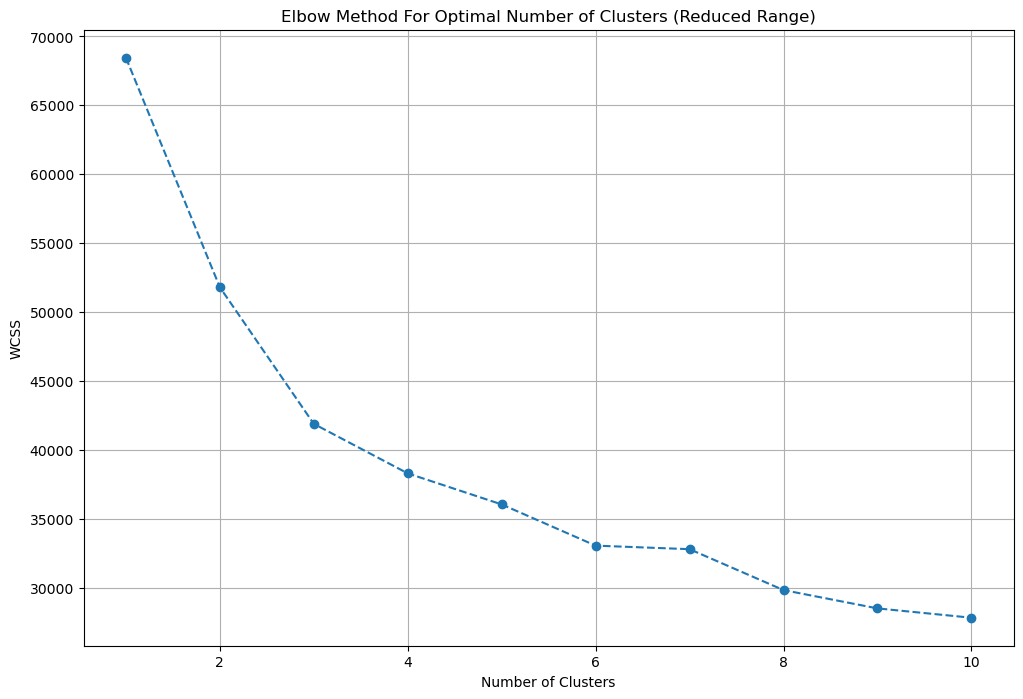

In [843]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [844]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [845]:
df = df.iloc[:,:-18]

In [846]:
df['furnishing_type'] = cluster_assignments

In [847]:
df.sample()
# 0 -> unfurnished# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type
1403,house,independent,sector 57,8.0,266666.0,300.0,Plot area 300(27.87 sq.m.),5,4,3,"pooja room,study room,servant room",2.0,North,Relatively New,"['Radhakrishna Shani Mandir', 'Sanatan Dharm Mandir', 'State bank ATM', 'Icici bank ATM', 'Standard chartered ATM', 'Vatsalya Clinic', 'Anand Hospital Gurgaon', 'Kriti Hospital', 'Surgicare Hospital Gurgaon', 'pracksht hospital', 'Meher Clinic', 'Bones Clinic - Orthopaedics', 'Vishesh Dental', 'Park Hospital Gurgaon', 'Neelkanth Health Care', 'Dr. Naresh Pandita', 'Arihant Hospital', 'Dr. Anuj Sharma', 'Wembley estate club', 'HUDA Office Complex', 'Medisca', 'Pernod Ricard Charitable Dispensary', 'SPAZE BUSINESS PARK', 'Unitech', 'Heera Fuel Station', 'HCG CNG Station', 'Hdfc bank', 'Hdfc bank and atm', 'Hdfc bank', '222', 'Pizza Hut', 'Madison and Pike', 'India', 'Haldiram', 'Raj Restaurant', 'Gurugram University', 'Kamla International', 'Amity Global School', 'St. Angels Sr', 'Manav Rachna School', 'Delhi Public School Primary Section', 'IILM', 'St. Angels Jr', 'Iilm University', 'Manav Rachna Swimming Pool']","['1 Geyser', '1 Chimney', '2 AC', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Fan', 'No Modular Kitchen', 'No Light', 'No Microwave', 'No Fridge', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Washing Machine', 'No Water Purifier']","['Water Storage', 'Visitor Parking', 'Waste Disposal', 'Rain Water Harvesting']",NaN,300.0,NaN,1,1,0,1,0,0


## 5.features

In [849]:
df[['society','features']].sample(5) 

,society,features
1819,the nav manesar apartment,"['Feng Shui / Vaastu Compliant', 'Piped-gas']"
3361,orchid petals,"['Feng Shui / Vaastu Compliant', 'Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Water Storage', 'Park', 'Visitor Parking']"
3585,independent,"['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'Park', 'Visitor Parking', 'Security Personnel', 'Waste Disposal', 'Rain Water Harvesting']"
1775,independent,['Park']
3651,independent,NaN


In [850]:
df['features'].isnull().sum()

635

In [851]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Palam Vihar', 'Park Hospital', 'Gurgaon Railway Station']","{'Bajghera Road': '800 Meter', 'Palam Vihar Halt': '2.5 KM', 'DPSG Palam Vihar': '3.1 KM', 'Park Hospital': '3.1 KM', 'Gurgaon Railway Station': '4.9 KM', 'The NorthCap University': '5.4 KM', 'Dwarka Expy': '1.2 KM', 'Hyatt Place Gurgaon Udyog Vihar': '7.7 KM', 'Dwarka Sector 21, Metro Station': '7.2 KM', 'Pacific D21 Mall': '7.4 KM', 'Indira Gandhi International Airport': '14.7 KM', 'Hamoni Golf Camp': '6.2 KM', 'Fun N Food Waterpark': '8.8 KM', 'Accenture DDC5': '9 KM'}",https://www.99acres.com/smartworld-one-dxp-sector-113-gurgaon-npxid-r400415,"{'2 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,370 sq.ft.', 'price-range': '₹ 2 - 2.4 Cr'}, '3 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '1,850 - 2,050 sq.ft.', 'price-range': '₹ 2.25 - 3.59 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Carpet Area', 'area': '2,600 sq.ft.', 'price-range': '₹ 3.24 - 4.56 Cr'}}","['Swimming Pool', 'Salon', 'Restaurant', 'Spa', 'Cafeteria', 'Sun Deck', '24x7 Security', 'Club House', 'Gated Community']"
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap University', 'Park Hospital, Palam Vihar', 'Pacific D21 Mall', 'Palam Vihar Halt Railway Station']","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The NorthCap University': '4.4 Km', 'Park Hospital, Palam Vihar': '1.4 Km', 'Pacific D21 Mall': '8.2 Km', 'Palam Vihar Halt Railway Station': '1.2 Km', 'Dwarka Sector 21 Metro Station': '8.1 Km', 'Dwarka Expressway': '450 m', 'Fun N Food Water Park': '8.1 Km', 'Indira Gandhi International Airport': '14.1 Km', 'Tau DeviLal Sports Complex': '11.2 Km', 'Hamoni Golf Camp': '5 Km', 'Hyatt Place': '6.1 Km', 'Altrade Business Centre': '11.2 Km'}",https://www.99acres.com/m3m-crown-sector-111-gurgaon-npxid-r404068,"{'3 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '1,605 - 2,170 sq.ft.', 'price-range': '₹ 2.2 - 3.03 Cr'}, '4 BHK': {'building_type': 'Apartment', 'area_type': 'Super Built-up Area', 'area': '2,248 - 2,670 sq.ft.', 'price-range': '₹ 3.08 - 3.73 Cr'}}","['Bowling Alley', 'Mini Theatre', 'Manicured Garden', 'Swimming Pool', 'Flower Garden', 'Reading Lounge', 'Golf Course', 'Barbecue', 'Sauna']"


In [852]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [853]:
temp_df = df[df['features'].isnull()]

In [854]:
temp_df.shape

(635, 26)

In [855]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [856]:
df.loc[temp_df.index,'features'] = x.values

In [857]:
df['features'].isnull().sum()

481

In [858]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [859]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [860]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
2052,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
2252,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
2202,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,1,0,0
891,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0,0
2065,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [861]:
features_binary_df.shape

(3803, 130)

In [862]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

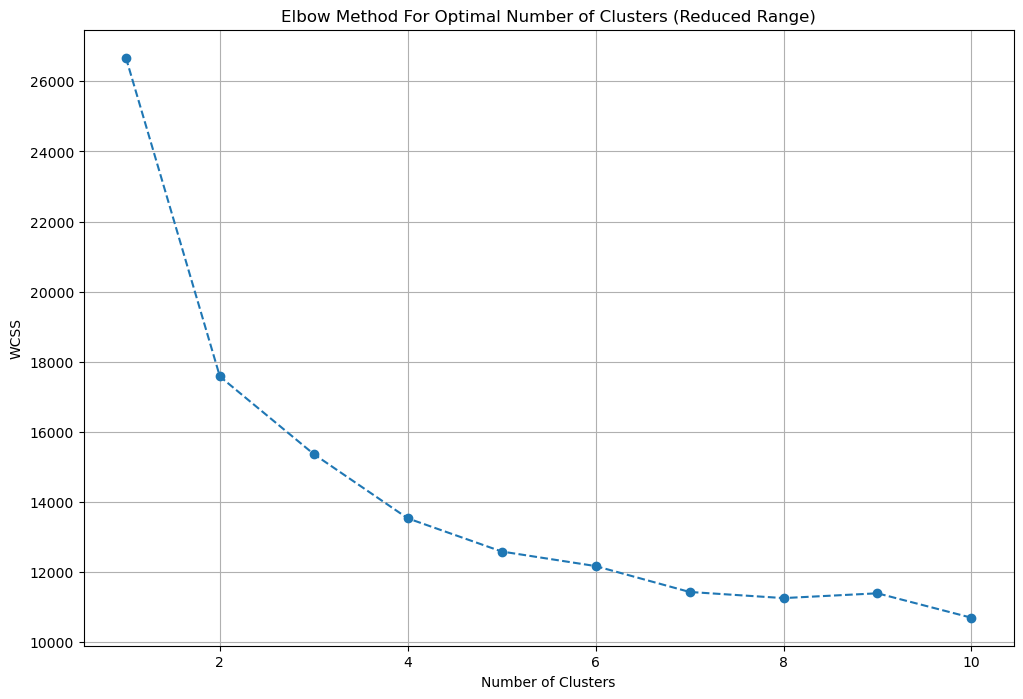

In [863]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [864]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)


In [865]:
df['luxury_score'] = luxury_score

In [866]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,house,bptp astaire gardens,sector 70a,6.50,27871.0,2332.0,Plot area 299(250 sq.m.),4,4,3+,"study room,servant room,pooja room",2.0,North-East,New Property,"['Sector 54 Chowk Metro Station', 'Airia Mall', 'Southern Peripheral Road', 'Badshahpur Sohna Rd Hwy', 'Kunskapsskolan International School', 'DPG Degree College', 'Indira Gandhi International Airport', 'Gurgaon Railway Station', 'Intellion Edge', 'Hyatt Regency Gurgaon', 'De Adventure Park', 'Tau DeviLal Sports Complex']","['5 Wardrobe', '9 Fan', '5 Geyser', '1 Stove', '18 Light', '8 AC', '1 Modular Kitchen', '1 Chimney', '1 Curtains', 'No Bed', 'No Dining Table', 'No Exhaust Fan', 'No Microwave', 'No Fridge', 'No Sofa', 'No TV', 'No Washing Machine', 'No Water Purifier']","['Centrally Air Conditioned', 'Water purifier', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']",NaN,299.0,NaN,1,1,0,1,0,1,"[Centrally Air Conditioned, Water purifier, Security / Fire Alarm, Feng Shui / Vaastu Compliant, Private Garden / Terrace, High Ceiling Height, Maintenance Staff, False Ceiling Lighting, Water Storage, Separate entry for servant room, No open drainage around, Bank Attached Property, Piped-gas, Internet/wi-fi connectivity, Recently Renovated, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors, Low Density Society, Waste Disposal, Rain Water Harvesting, Fitness Centre / GYM, Club house / Community Center]",160
1,house,central park flower valley cerise floors,sector 33,1.35,11157.0,1210.0,Built Up area: 1210 (112.41 sq.m.),2,2,2,study room,4.0,East,New Property,"['Sector 55-56, Sector 56', 'M3m 65th Avenue Mall', 'Emerald Plaza Mall', 'Omaxe City Centre', 'Airia Mall', 'Basant Valley Global School', 'CK Birla Hospital, Gurgaon', 'Park Hospital (Gurugram, Haryana)', 'W Pratiksha Hospital', 'Artemis Hospital Gurgaon', 'Suncity Success Tower', 'Splendor Trade Tower', 'Emaar Digital Greens Tower A', '24 Seven Filling Station', 'HP PETROL PUMP, Golf Course Ext Rd']","['3 Fan', '1 Fridge', '1 Washing Machine', '1 Microwave', '3 Light', '1 Chimney', '3 AC', '1 Modular Kitchen', 'No Bed', 'No Curtains', 'No Dining Table', 'No Exhaust Fan', 'No Geyser', 'No Sofa', 'No Stove', 'No TV', 'No Wardrobe', 'No Water Purifier']","['Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'Water Storage', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Fitness Centre / GYM', 'Waste Disposal', 'Rain Water Harvesting', 'Club house / Community Center']",NaN,1210.0,NaN,1,0,0,0,0,2,"[Feng Shui / Vaastu Compliant, Private Garden / Terrace, High Ceiling Height, Maintenance Staff, Water Storage, Visitor Parking, Swimming Pool, Park, Security Personnel, Natural Light, Airy Rooms, Spacious Interiors, Fitness Centre / GYM, Waste Disposal, Rain Water Harvesting, Club house / Community Center]",107
2,flat,conscient heritage max,sector 102,1.82,9371.0,1942.0,Super Built up area 1942(180.42 sq.m.),3,4,3+,servant room,15.0,East,Moderately Old,"['Huda Metro Station', 'Ocus Medley Mall', 'The Esplanade Mall', 'Gurugram Road',

In [867]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [868]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2146,flat,m3m heights,sector 65,3.67,17990.0,2040.0,Super Built up area 2040(189.52 sq.m.),3,3,2,27.0,NaN,Under Construction,2040.0,NaN,NaN,0,1,0,0,0,0,43
1177,flat,chanderlok society,sector 28,0.90,7234.0,1244.0,Carpet area: 1244 (115.57 sq.m.),4,2,3+,1.0,NaN,Old Property,NaN,NaN,1244.0,0,0,0,0,0,0,0
1564,house,independent,sector 43,3.00,53763.0,558.0,Plot area 62(51.84 sq.m.),12,12,3+,5.0,West,New Property,NaN,558.0,NaN,0,0,0,0,1,2,20
1824,flat,bestech park view residency,sector 2,1.50,7825.0,1917.0,Super Built up area 1920(178.37 sq.m.),3,4,3+,10.0,North-East,Moderately Old,1920.0,NaN,NaN,0,1,0,0,0,0,93
1148,flat,breeze global heights,sector 33,0.40,6421.0,623.0,Built Up area: 623 (57.88 sq.m.)Carpet area: 599 sq.ft. (55.65 sq.m.),2,2,2,4.0,NaN,Undefined,NaN,623.0,599.0,0,0,0,0,0,0,0


In [869]:
df.shape

(3803, 23)

In [870]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)